In [218]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import math

In [219]:
#Reading in data

df_AsemiHot = pd.read_table("Asemi_Hot_2.dat") #This is the full temperature set
df_BsemiHot = pd.read_table("BSemi_Hot.dat")
df_Asemi = pd.read_table("Asemi.dat")
df_Bsemi = pd.read_table("BSemi.dat")
df_BSCCO = pd.read_table("BSCCO.dat")

In [220]:
ASemiColumn = {f"Column_{i}": df_Asemi.iloc[:, i] for i in range(df_Asemi.shape[1])} #Column_2 is temp, Column_2 is sample resistance (Ω), etc.
BSemiColumn = {f"Column_{i}": df_Bsemi.iloc[:, i] for i in range(df_Bsemi.shape[1])} 
ASemiHotColumn = {f"Column_{i}": df_AsemiHot.iloc[:, i] for i in range(df_AsemiHot.shape[1])} 
BSemiHotColumn = {f"Column_{i}": df_BsemiHot.iloc[:, i] for i in range(df_BsemiHot.shape[1])} 
BSCCOColumn = {f"Column_{i}": df_BSCCO.iloc[:, i] for i in range(df_BSCCO.shape[1])} 

#print(ASemiColumn["Column_6"].values) to get values

In [234]:

#Eliminating cool down and heat up portions of data
b=np.argmin(ASemiColumn["Column_2"].values) #Eliminating cool down values
e=len(ASemiColumn["Column_2"].values)
ASemiColumn = {col: row[b:e] for col, row in ASemiColumn.items()}

b=np.argmin(BSemiColumn["Column_2"].values) #Eliminating cool down values
e=len(BSemiColumn["Column_2"].values)
BSemiColumn = {col: row[b:e] for col, row in BSemiColumn.items()}

b=np.argmin(BSCCOColumn["Column_2"].values) #Eliminating cool down values
e=len(BSCCOColumn["Column_2"].values)
BSCCOColumn = {col: row[b:e] for col, row in BSCCOColumn.items()}

b=np.argmax(BSemiHotColumn["Column_2"].values) #Eliminating heat up values
e=len(BSemiHotColumn["Column_2"].values)
BSemiHotColumn = {col: row[b:e] for col, row in BSemiHotColumn.items()}

b=np.argmax(ASemiHotColumn["Column_2"].values) #Eliminating heat up values
e=len(ASemiHotColumn["Column_2"].values)
ASemiHotColumn = {col: row[b:e] for col, row in ASemiHotColumn.items()}

In [235]:
#I want to add together the hot and cold datas
ASemi = {}
BSemi = {}
for col in ASemiColumn:
    ASemi[col] = np.concatenate([ASemiColumn[col].values,ASemiHotColumn[col].values ])
for col in BSemiColumn:
    BSemi[col] = np.concatenate([BSemiColumn[col].values,BSemiHotColumn[col].values ])
ASemiOrd=[]
BSemiOrd=[]
#now going to reorganize by temperature 
ASemi = {col: ASemi[col][np.argsort(ASemi["Column_2"])] for col in ASemi} #looping over temperature and picking index st temp is sorted, then rebuilding ASemi
BSemi = {col: BSemi[col][np.argsort(BSemi["Column_2"])] for col in BSemi}

print(ASemi["Column_2"])

[ 78.149333  78.1495    78.1495   ... 364.074483 367.527333 370.384408]


Slope should be -6614.831147731227


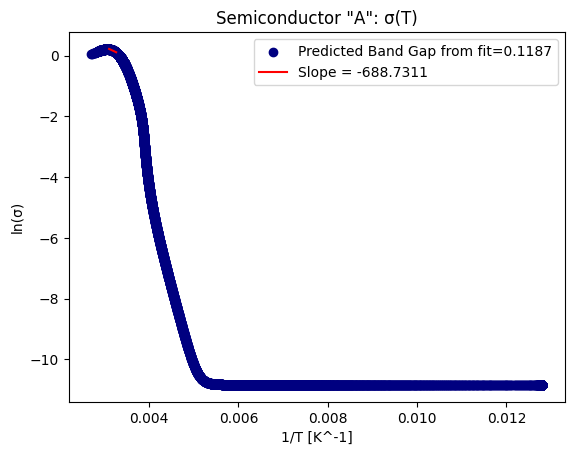

In [240]:
##############High Temp/ Intrinsic Region? ###############

Area= 5*10**-3*3*10**-3 #m^2
Length= 5*10**-3 #m

Asemiresistivity=Area/Length*ASemi["Column_3"] #Resistance to conductivity 
AsemiConductivity=1/Asemiresistivity

invT = 1/ASemi["Column_2"]
ln_sigma = np.log(AsemiConductivity)


plotstart=len(invT)-1300 #fitting largest 1000 temps
plotend=len(invT)-500 #fitting largest 1000 temps


def f(x,A,B): #Fit
    f_vals = A*x+B 
    return f_vals

popt, pcov = curve_fit(f,(invT)[plotstart:plotend],(ln_sigma)[plotstart:plotend], p0=None)


Eg= 1.14 #Silicon eV
kb=8.617*10**-5 #eV/K
plt.scatter(invT,ln_sigma, color='navy',label=f'Predicted Band Gap from fit={round(-popt[0]*2*kb,5)}')
plt.plot(invT[plotstart:plotend], f(invT[plotstart:plotend], *popt), color='red', label=f'Slope = {round(popt[0],4)}')
plt.xlabel('1/T [K^-1]')
plt.ylabel('ln(σ)') # sigma in [1/(Ωm)]^-1
plt.title('Semiconductor "A": σ(T)')
plt.legend()
print(f'Slope should be -{Eg/(2*kb)}')

#the slope/band gap disparity seems to imply this isnt high temp intrinsic region

Slope should be -6614.831147731227


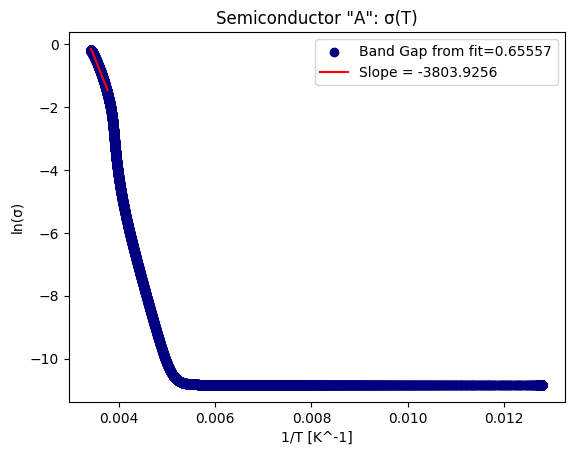

In [224]:
##############Mid Temp/ Extrinsic Region? ###############

Area= 5*10**-3*3*10**-3 #m^2
Length= 5*10**-3 #m

Asemiresistivity=Area/Length*ASemiColumn["Column_3"].values #Resistance to conductivity 
AsemiConductivity=1/Asemiresistivity

b=np.argmin(ASemiColumn["Column_2"].values) #Eliminating cool down values
e=len(ASemiColumn["Column_2"].values)
invT = 1 / ASemiColumn["Column_2"].values[b:e]
ln_sigma = np.log(AsemiConductivity[b:e])


plotstart=len(invT)-3000
plotend=len(invT) #fitting largest 1000 temps


def f(x,A,B): #Fit
    f_vals = A*x+B 
    return f_vals

popt, pcov = curve_fit(f,(invT)[plotstart:plotend],(ln_sigma)[plotstart:plotend], p0=None)


Eg= 1.14 #Silicon eV
kb=8.617*10**-5 #eV/K
plt.scatter(invT,ln_sigma, color='navy',label=f'Band Gap from fit={round(-popt[0]*2*kb,5)}')
plt.plot(invT[plotstart:plotend], f(invT[plotstart:plotend], *popt), color='red', label=f'Slope = {round(popt[0],4)}')
plt.xlabel('1/T [K^-1]')
plt.ylabel('ln(σ)') # sigma in [1/(Ωm)]^-1
plt.title('Semiconductor "A": σ(T)')
plt.legend()
print(f'Slope should be -{Eg/(2*kb)}')

